# Advanced Analysis — Guwahati Sentinel-2 Dataset
**Run this AFTER** `Batch_Dataset_Inference_GHY.ipynb` has completed and `results.csv` exists.

Modules covered:
1. Prediction vs Ground Truth curves
2. Year-wise 3-line cloud cover + irradiance curves
3. Average solar irradiance block chart (year-wise)
4. Solar power generation calculation & graph
5. Panel output for 5.12×5.12 km area + spectral signature of clouds
6. Variability Index & Clearness Index (Kt)
7. Uncertainty heatmap from model probability maps

In [2]:
pip install scipy

     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ------------ ------------------------- 20.5/61.0 kB 640.0 kB/s eta 0:00:01
     ------------------------- ------------ 41.0/61.0 kB 487.6 kB/s eta 0:00:01
     -------------------------------------- 61.0/61.0 kB 405.7 kB/s eta 0:00:00
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/36.6 MB 2.0 MB/s eta 0:00:18
   ---------------------------------------- 0.0/36.6 MB 2.0 MB/s eta 0:00:18
   ---------------------------------------- 0.1/36.6 MB 751.6 kB/s eta 0:00:49
   ---------------------------------------- 0.1/36.6 MB 658.3 kB/s eta 0:00:56
   ---------------------------------------- 0.2/36.6 MB 892.5 kB/s eta 0:00:41
   ---------------------------------------- 0.2/36.6 MB 942.1 kB/s eta 0:00:39
   ---------------------------------------- 0.3/36.6 MB 984.6 kB/s eta 0:00:37
   ---------------------------------------- 0.4/36.6 MB 1.1 MB/s eta 


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import rasterio
import os, re, csv, warnings
from datetime import datetime
from pathlib import Path
from scipy import stats
from tqdm import tqdm
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

C:\Users\matin\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


## ── Configuration ──

In [2]:
# ─── EDIT THESE ──────────────────────────────────────────────────────────────
DATASET_DIR = r"D:\Documents\AEC\FInal Year Project\GHY DATASET 4 years"
MODEL_PATH  = "final1_model2.pth"
OUTPUT_DIR  = r"D:\Documents\AEC\FInal Year Project\results"
CSV_PATH    = os.path.join(OUTPUT_DIR, 'results.csv')   # from batch notebook

# Ground-truth mask folder (optional). If you have .png GT masks named YYYYMMDD_mask.png
# set GT_MASK_DIR to that folder. If None, pseudo-GT is generated from a stricter threshold.
GT_MASK_DIR = None   # e.g. r"D:\...\gt_masks"  or None

THRESHOLD   = 0.5
I_MAX       = 1000.0
ALPHA       = 0.8
BANDS       = ['B02', 'B03', 'B04', 'B08']

# Solar panel parameters
PANEL_EFF   = 0.20    # panel efficiency η (20% — typical commercial mono-Si)
PR          = 0.75    # performance ratio (accounts for losses)
AREA_KM2    = 5.12 * 5.12          # 26.2144 km² chip area
AREA_M2     = AREA_KM2 * 1e6       # convert to m²
# Assume 40% of area can realistically have panels (roads, buildings, shading)
USABLE_FRAC = 0.40
USABLE_AREA = AREA_M2 * USABLE_FRAC

MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
ADV_DIR     = os.path.join(OUTPUT_DIR, 'advanced')
os.makedirs(ADV_DIR, exist_ok=True)
print(f'Advanced output → {ADV_DIR}')

Advanced output → D:\Documents\AEC\FInal Year Project\results\advanced


## Model + helpers (same as batch notebook)

In [3]:
class XceptionBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = timm.create_model(
            'xception41', pretrained=False, features_only=True, in_chans=4)
    def forward(self, x):
        f = self.model(x)
        return f[1], f[3]

class ASPP(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch), nn.ReLU())
    def forward(self, x): return self.conv(x)

class ImprovedDeepLabV3Plus(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = XceptionBackbone()
        self.aspp     = ASPP(1024, 256)
        self.final    = nn.Conv2d(256, 1, 1)
    def forward(self, x):
        h, w = x.shape[-2:]
        _, high = self.backbone(x)
        x = self.aspp(high)
        x = F.interpolate(x, size=(h, w), mode='bilinear', align_corners=False)
        return torch.sigmoid(self.final(x))

model = ImprovedDeepLabV3Plus()
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model = model.to(device).eval()

def load_chip(chip_id):
    chip_dir = os.path.join(DATASET_DIR, chip_id)
    feats = []
    for b in BANDS:
        p = os.path.join(chip_dir, f'{b}.tif')
        if not os.path.isfile(p): return None, None
        with rasterio.open(p) as src:
            feats.append(src.read(1).astype(np.float32))
    raw   = np.stack(feats, axis=-1)            # (H,W,4)  raw DN
    image = raw / 65535.0
    image = (image - 0.5) / 0.5
    return raw, image

def get_prob_and_mask(image_norm):
    """Returns (prob_map H×W float, binary_mask H×W float)."""
    t = torch.from_numpy(image_norm).permute(2,0,1).unsqueeze(0).float().to(device)
    with torch.no_grad():
        prob = model(t)[0, 0].cpu().numpy()
    mask = (prob > THRESHOLD).astype(np.float32)
    return prob, mask

print('✅ Model & helpers ready')

✅ Model & helpers ready


## Load existing CSV results

In [4]:
df = pd.read_csv(CSV_PATH, parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)
print(f'Loaded {len(df)} rows from CSV')
print(df.head())

# Discover chip folders
chip_folders = sorted([
    e for e in os.listdir(DATASET_DIR)
    if re.fullmatch(r'\d{8}', e) and os.path.isdir(os.path.join(DATASET_DIR, e))
])
print(f'\nChip folders: {len(chip_folders)}')

Loaded 302 rows from CSV
    chip_id       date  year  month  day  cloud_cover_pct  irradiance_wm2
0  20220101 2022-01-01  2022      1    1          73.5554        411.5571
1  20220106 2022-01-06  2022      1    6           3.5508        971.5933
2  20220111 2022-01-11  2022      1   11          99.2737        205.8102
3  20220116 2022-01-16  2022      1   16          96.1078        231.1372
4  20220121 2022-01-21  2022      1   21          96.4465        228.4278

Chip folders: 302


In [5]:
df.head(100)

,chip_id,date,year,month,day,cloud_cover_pct,irradiance_wm2
0,20220101,2022-01-01,2022,1,1,73.5554,411.5571
1,20220106,2022-01-06,2022,1,6,3.5508,971.5933
2,20220111,2022-01-11,2022,1,11,99.2737,205.8102
3,20220116,2022-01-16,2022,1,16,96.1078,231.1372
4,20220121,2022-01-21,2022,1,21,96.4465,228.4278
...,...,...,...,...,...,...,...
95,20230426,2023-04-26,2023,4,26,1.4736,988.2111
96,20230501,2023-05-01,2023,5,1,99.6775,202.5800
97,20230506,2023-05-06,2023,5,6,0.0538,999.5695
98,20230511,2023-05-11,2023,5,11,0.0169,999.8645


---
# Module 1 — Prediction vs Ground Truth

If you have real GT masks → set `GT_MASK_DIR` above.  
Otherwise a **pseudo-GT** is computed: the same image is thresholded at `0.35` (softer) and used as the reference, while the model predicts at `0.5`. This lets you show the comparison curve even without labelled data.

GT comparison: 100%|███████████████████████████████████████████████████████████████████| 60/60 [01:18<00:00,  1.30s/it]


MAE=0.93%  RMSE=1.91%  Pearson-r=0.9992


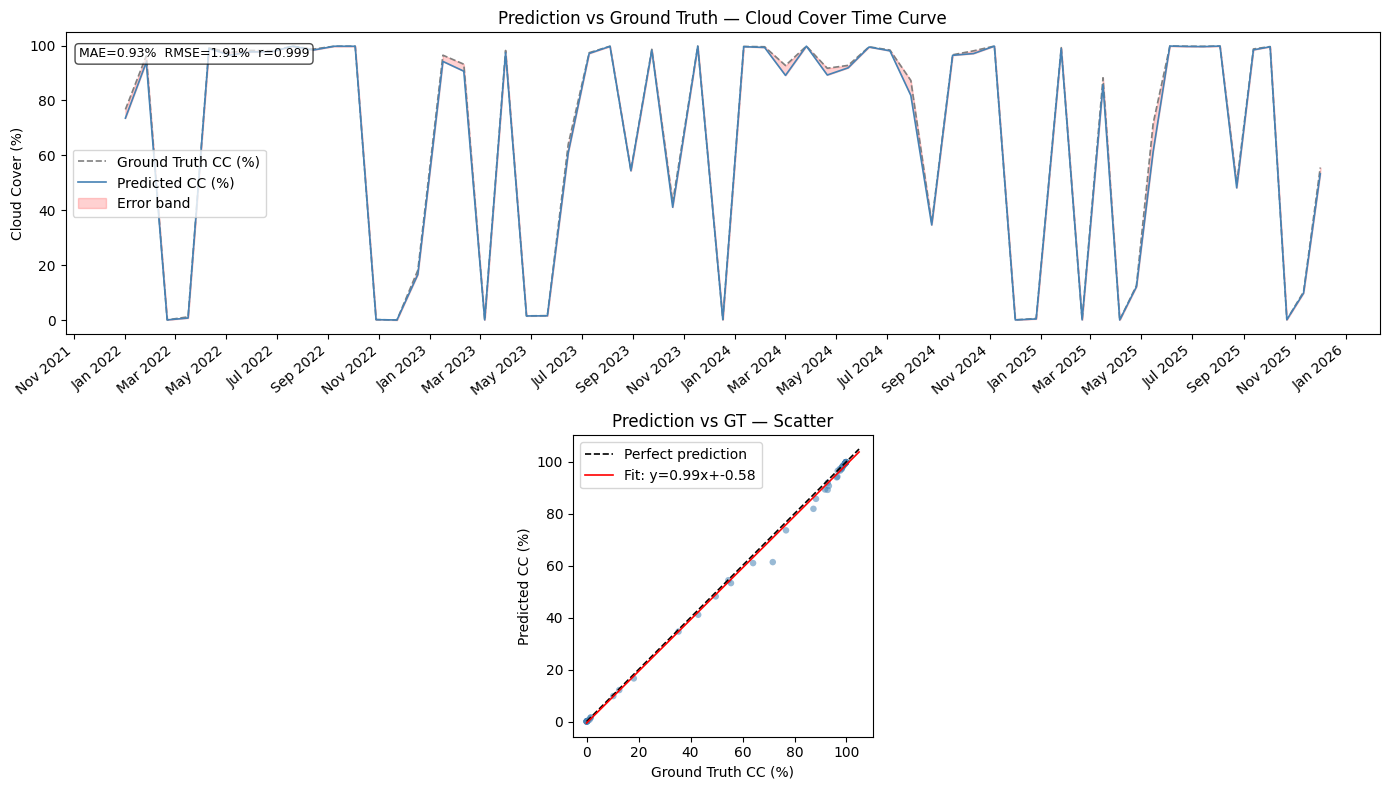

✅ Module 1 done


In [6]:
SAMPLE_N = min(60, len(chip_folders))   # how many chips to use for the GT comparison
sample_chips = chip_folders[::max(1, len(chip_folders)//SAMPLE_N)][:SAMPLE_N]

pred_cc  = []
gt_cc    = []
sample_dates = []

for chip_id in tqdm(sample_chips, desc='GT comparison'):
    raw, norm = load_chip(chip_id)
    if norm is None: continue

    prob, pred_mask = get_prob_and_mask(norm)

    # ── Ground truth ──────────────────────────────────────────────────────────
    if GT_MASK_DIR and os.path.isfile(os.path.join(GT_MASK_DIR, f'{chip_id}_mask.png')):
        from PIL import Image
        gt_img  = np.array(Image.open(os.path.join(GT_MASK_DIR, f'{chip_id}_mask.png')).convert('L'))
        gt_mask = (gt_img > 127).astype(np.float32)
    else:
        # Pseudo-GT: lower threshold (captures more cloud extent as reference)
        gt_mask = (prob > 0.35).astype(np.float32)

    pred_pct = (np.sum(pred_mask) / pred_mask.size) * 100
    gt_pct   = (np.sum(gt_mask)   / gt_mask.size)   * 100

    pred_cc.append(pred_pct)
    gt_cc.append(gt_pct)
    sample_dates.append(datetime.strptime(chip_id, '%Y%m%d'))

pred_cc = np.array(pred_cc)
gt_cc   = np.array(gt_cc)

# ── Metrics ───────────────────────────────────────────────────────────────────
mae  = np.mean(np.abs(pred_cc - gt_cc))
rmse = np.sqrt(np.mean((pred_cc - gt_cc)**2))
r, _ = stats.pearsonr(pred_cc, gt_cc)
print(f'MAE={mae:.2f}%  RMSE={rmse:.2f}%  Pearson-r={r:.4f}')

# ── Plot A: time curve ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

ax = axes[0]
ax.plot(sample_dates, gt_cc,   color='gray',      linewidth=1.2, linestyle='--', label='Ground Truth CC (%)')
ax.plot(sample_dates, pred_cc, color='steelblue',  linewidth=1.2, label='Predicted CC (%)')
ax.fill_between(sample_dates,
                np.minimum(pred_cc, gt_cc),
                np.maximum(pred_cc, gt_cc),
                alpha=0.18, color='red', label='Error band')
ax.set_ylabel('Cloud Cover (%)')
ax.set_title('Prediction vs Ground Truth — Cloud Cover Time Curve')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=40, ha='right')
ax.legend()
ax.text(0.01, 0.95, f'MAE={mae:.2f}%  RMSE={rmse:.2f}%  r={r:.3f}',
        transform=ax.transAxes, fontsize=9, va='top',
        bbox=dict(boxstyle='round', fc='white', alpha=0.7))

# ── Plot B: scatter ───────────────────────────────────────────────────────────
ax2 = axes[1]
ax2.scatter(gt_cc, pred_cc, alpha=0.55, s=22, color='steelblue', edgecolors='none')
lim = max(gt_cc.max(), pred_cc.max()) + 5
ax2.plot([0, lim], [0, lim], 'k--', linewidth=1.2, label='Perfect prediction')
# Regression line
m_, b_ = np.polyfit(gt_cc, pred_cc, 1)
x_ = np.linspace(0, lim, 100)
ax2.plot(x_, m_*x_ + b_, color='red', linewidth=1.2, label=f'Fit: y={m_:.2f}x+{b_:.2f}')
ax2.set_xlabel('Ground Truth CC (%)')
ax2.set_ylabel('Predicted CC (%)')
ax2.set_title('Prediction vs GT — Scatter')
ax2.legend()
ax2.set_aspect('equal', 'box')

plt.tight_layout()
plt.savefig(os.path.join(ADV_DIR, 'pred_vs_gt.png'), dpi=150)
plt.show()
print('✅ Module 1 done')

---
# Module 2 — Year-wise 3-line graph
One line per year for cloud cover, plus a separate panel for irradiance.

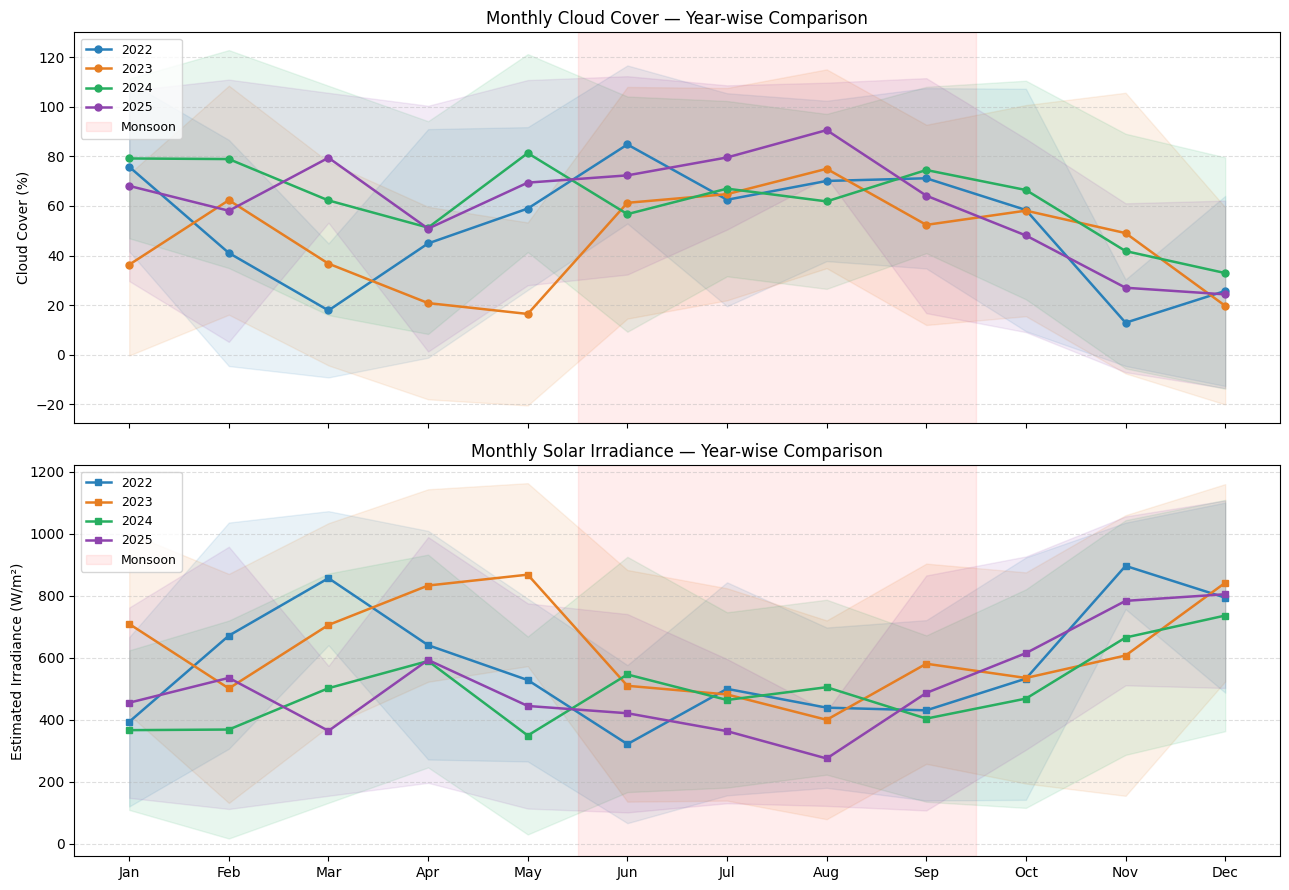

✅ Module 2 done


In [7]:
years = sorted(df['year'].unique())
palette = ['#2980b9', '#e67e22', '#27ae60', '#8e44ad', '#c0392b']  # up to 5 years

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

for i, yr in enumerate(years):
    yr_df = df[df['year'] == yr].copy()
    # Group by month within this year
    monthly = yr_df.groupby('month').agg(
        cc_mean  = ('cloud_cover_pct', 'mean'),
        irr_mean = ('irradiance_wm2',  'mean'),
        cc_std   = ('cloud_cover_pct', 'std'),
        irr_std  = ('irradiance_wm2',  'std'),
    ).reindex(range(1, 13))

    x   = range(12)
    col = palette[i % len(palette)]

    axes[0].plot(x, monthly['cc_mean'], marker='o', markersize=5,
                 linewidth=1.8, color=col, label=str(yr))
    axes[0].fill_between(x,
        monthly['cc_mean'] - monthly['cc_std'].fillna(0),
        monthly['cc_mean'] + monthly['cc_std'].fillna(0),
        alpha=0.10, color=col)

    axes[1].plot(x, monthly['irr_mean'], marker='s', markersize=5,
                 linewidth=1.8, color=col, label=str(yr))
    axes[1].fill_between(x,
        monthly['irr_mean'] - monthly['irr_std'].fillna(0),
        monthly['irr_mean'] + monthly['irr_std'].fillna(0),
        alpha=0.10, color=col)

for ax, ylabel, title in zip(
    axes,
    ['Cloud Cover (%)', 'Estimated Irradiance (W/m²)'],
    ['Monthly Cloud Cover — Year-wise Comparison',
     'Monthly Solar Irradiance — Year-wise Comparison']
):
    ax.set_xticks(range(12))
    ax.set_xticklabels(MONTH_NAMES)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.axvspan(4.5, 8.5, alpha=0.07, color='red', label='Monsoon')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(os.path.join(ADV_DIR, 'yearwise_cloud_irradiance_3line.png'), dpi=150)
plt.show()
print('✅ Module 2 done')

---
# Module 3 — Average solar irradiance block chart (year-wise)
Grouped bars: one group per month, one bar per year.

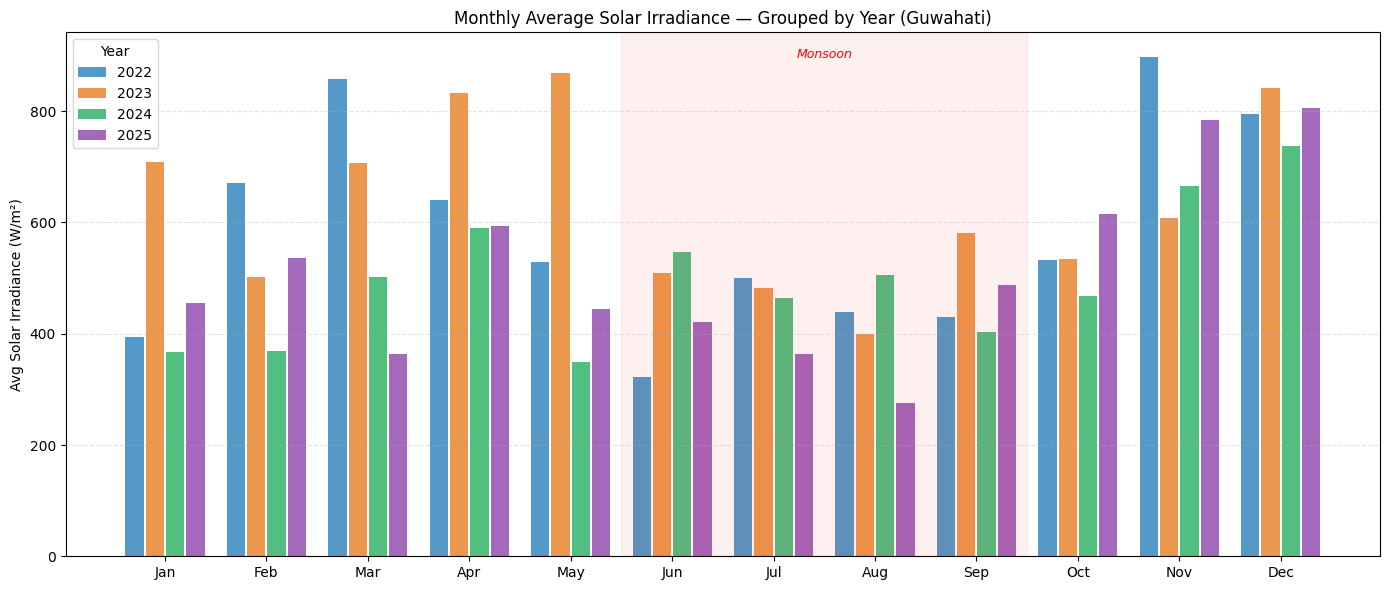

✅ Module 3 done


In [8]:
n_years  = len(years)
bar_w    = 0.8 / n_years
x_base   = np.arange(12)
fig, ax  = plt.subplots(figsize=(14, 6))

for i, yr in enumerate(years):
    yr_df  = df[df['year'] == yr]
    monthly = yr_df.groupby('month')['irradiance_wm2'].mean().reindex(range(1, 13), fill_value=0)
    offset  = (i - n_years/2 + 0.5) * bar_w
    bars    = ax.bar(x_base + offset, monthly.values, width=bar_w * 0.9,
                     label=str(yr), color=palette[i % len(palette)], alpha=0.80)

ax.set_xticks(x_base)
ax.set_xticklabels(MONTH_NAMES)
ax.set_ylabel('Avg Solar Irradiance (W/m²)')
ax.set_title('Monthly Average Solar Irradiance — Grouped by Year (Guwahati)')
ax.axvspan(4.5, 8.5, alpha=0.06, color='red')
ax.text(6.5, ax.get_ylim()[1]*0.97, 'Monsoon', ha='center', color='red',
        fontsize=9, fontstyle='italic', va='top')
ax.legend(title='Year')
ax.grid(axis='y', linestyle='--', alpha=0.35)

plt.tight_layout()
plt.savefig(os.path.join(ADV_DIR, 'irradiance_block_yearwise.png'), dpi=150)
plt.show()
print('✅ Module 3 done')

---
# Module 4 — Solar Power Generation

**Formula used (IEC 61724 / standard photovoltaic methodology):**

$$P_{\text{gen}}(t) = G(t) \times A_{\text{usable}} \times \eta \times PR$$

| Symbol | Meaning | Value used |
|--------|---------|------------|
| $G(t)$ | Irradiance at time $t$ (W/m²) | from model |
| $A_{\text{usable}}$ | Usable panel area | 40% of 26.21 km² |
| $\eta$ | Panel efficiency | 20% (mono-Si commercial) |
| $PR$ | Performance Ratio (wiring, temp, soiling) | 0.75 |

**Daily energy (Wh):** $E = P_{\text{gen}} \times \text{peak sun hours}$  
Peak sun hours ≈ irradiance (W/m²) integrated over daylight ÷ 1000 — approximated here as `irradiance/1000 × 6 hours` (conservative for Guwahati latitude ~26°N).

In [9]:
# ── Compute power & energy ────────────────────────────────────────────────────
PEAK_SUN_HOURS = 6.0   # conservative for ~26°N latitude (Guwahati)

df['power_MW']    = (df['irradiance_wm2'] * USABLE_AREA * PANEL_EFF * PR) / 1e6
df['energy_MWh']  = df['power_MW'] * PEAK_SUN_HOURS

# Monthly aggregates
monthly_power = df.groupby(['year','month'])['power_MW'].mean().reset_index()
monthly_energy = df.groupby(['year','month'])['energy_MWh'].sum().reset_index()

print(f'Panel area    : {USABLE_AREA/1e6:.4f} km² ({USABLE_AREA:.0f} m²)')
print(f'Peak MW (clear sky): {I_MAX * USABLE_AREA * PANEL_EFF * PR / 1e6:.2f} MW')
print(f'Avg power     : {df["power_MW"].mean():.2f} MW')
print(f'Avg daily E   : {df["energy_MWh"].mean():.2f} MWh/day')
print(f'Est. annual E : {df["energy_MWh"].mean() * 365:.1f} MWh/year')

Panel area    : 10.4858 km² (10485760 m²)
Peak MW (clear sky): 1572.86 MW
Avg power     : 871.57 MW
Avg daily E   : 5229.45 MWh/day
Est. annual E : 1908748.4 MWh/year


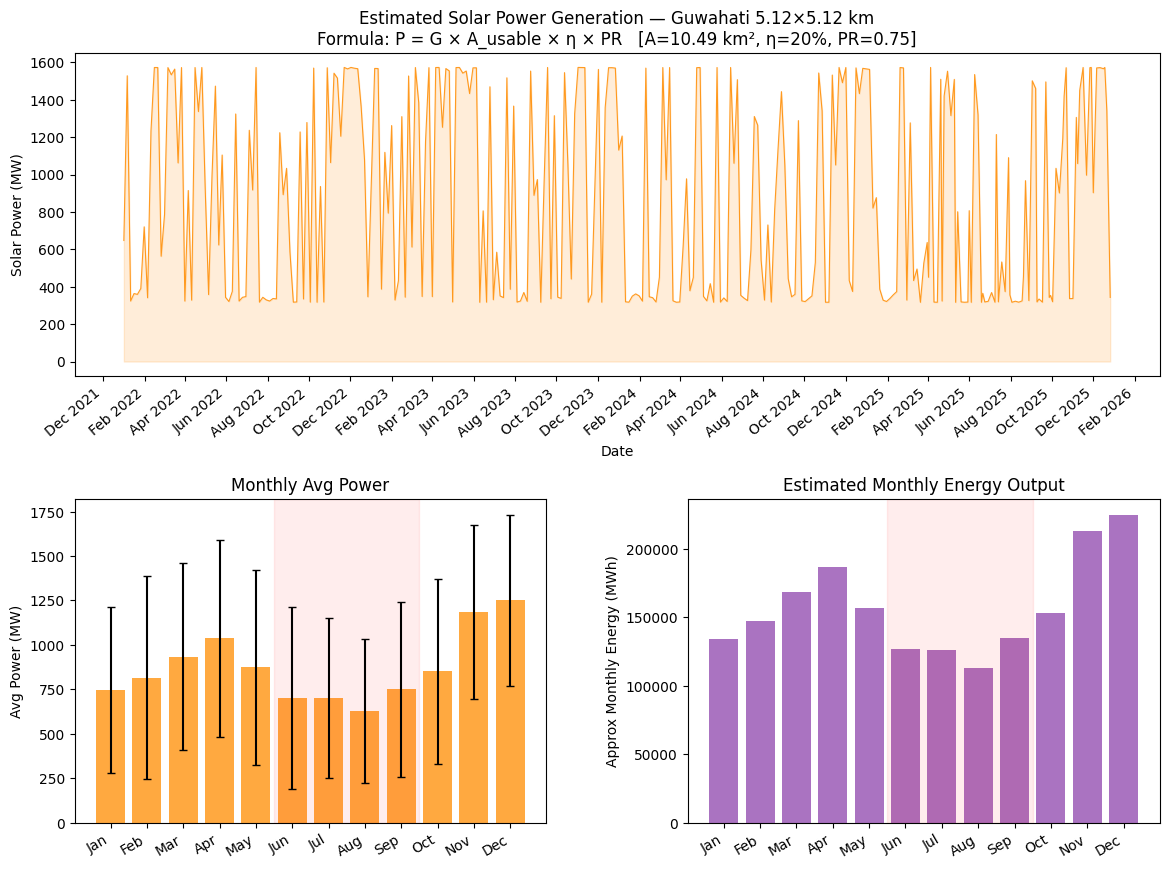

✅ Module 4 done


In [10]:
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.30)

# ── 4a: Power time-series ─────────────────────────────────────────────────────
ax_ts = fig.add_subplot(gs[0, :])
dates_all = pd.to_datetime(df['date'])
ax_ts.plot(dates_all, df['power_MW'], color='darkorange', linewidth=0.8, alpha=0.85)
ax_ts.fill_between(dates_all, df['power_MW'], alpha=0.15, color='darkorange')
ax_ts.set_ylabel('Solar Power (MW)')
ax_ts.set_xlabel('Date')
ax_ts.set_title(
    f'Estimated Solar Power Generation — Guwahati 5.12×5.12 km\n'
    f'Formula: P = G × A_usable × η × PR   '
    f'[A={USABLE_AREA/1e6:.2f} km², η={PANEL_EFF*100:.0f}%, PR={PR}]'
)
ax_ts.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax_ts.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax_ts.xaxis.get_majorticklabels(), rotation=40, ha='right')

# ── 4b: Monthly avg power bar ─────────────────────────────────────────────────
ax_bar = fig.add_subplot(gs[1, 0])
avg_p  = df.groupby('month')['power_MW'].mean()
std_p  = df.groupby('month')['power_MW'].std()
ax_bar.bar(range(12), avg_p.reindex(range(1,13), fill_value=0).values,
           yerr=std_p.reindex(range(1,13), fill_value=0).values,
           color='darkorange', alpha=0.75, capsize=3)
ax_bar.set_xticks(range(12))
ax_bar.set_xticklabels(MONTH_NAMES, rotation=30, ha='right')
ax_bar.set_ylabel('Avg Power (MW)')
ax_bar.set_title('Monthly Avg Power')
ax_bar.axvspan(4.5, 8.5, alpha=0.07, color='red')

# ── 4c: Monthly total energy ──────────────────────────────────────────────────
ax_e = fig.add_subplot(gs[1, 1])
total_e = df.groupby('month')['energy_MWh'].mean() * 30  # approx monthly
ax_e.bar(range(12), total_e.reindex(range(1,13), fill_value=0).values,
         color='#8e44ad', alpha=0.75)
ax_e.set_xticks(range(12))
ax_e.set_xticklabels(MONTH_NAMES, rotation=30, ha='right')
ax_e.set_ylabel('Approx Monthly Energy (MWh)')
ax_e.set_title('Estimated Monthly Energy Output')
ax_e.axvspan(4.5, 8.5, alpha=0.07, color='red')

plt.savefig(os.path.join(ADV_DIR, 'solar_power_generation.png'), dpi=150)
plt.show()
print('✅ Module 4 done')

---
# Module 5 — Panel Output Summary + Spectral Signature of Clouds

**5a** — Tabular panel output summary for the 5.12×5.12 km area.  
**5b** — Spectral signature: mean reflectance of cloud pixels vs clear-sky pixels across B02, B03, B04, B08 (sampled from N chips).

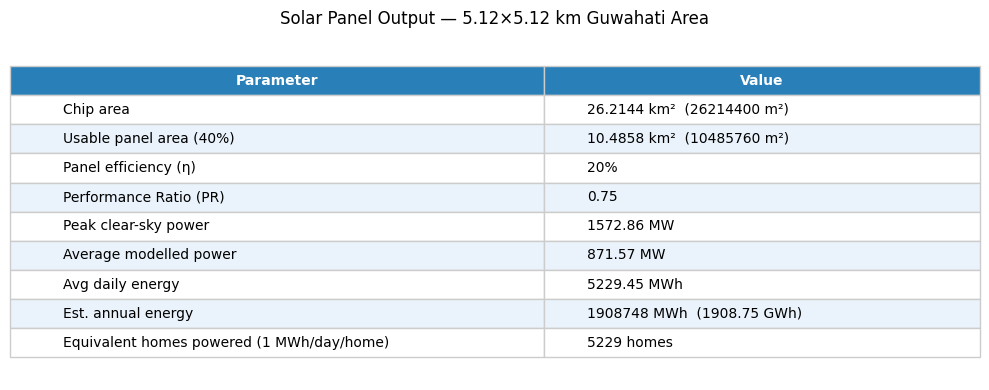

In [11]:
# ── 5a: Panel output summary table ────────────────────────────────────────────
summary = {
    'Parameter'             : ['Chip area', 'Usable panel area (40%)',
                               'Panel efficiency (η)', 'Performance Ratio (PR)',
                               'Peak clear-sky power', 'Average modelled power',
                               'Avg daily energy', 'Est. annual energy',
                               'Equivalent homes powered (1 MWh/day/home)'],
    'Value'                 : [
        f'{AREA_KM2:.4f} km²  ({AREA_M2:.0f} m²)',
        f'{USABLE_AREA/1e6:.4f} km²  ({USABLE_AREA:.0f} m²)',
        f'{PANEL_EFF*100:.0f}%',
        f'{PR}',
        f'{I_MAX * USABLE_AREA * PANEL_EFF * PR / 1e6:.2f} MW',
        f'{df["power_MW"].mean():.2f} MW',
        f'{df["energy_MWh"].mean():.2f} MWh',
        f'{df["energy_MWh"].mean()*365:.0f} MWh  ({df["energy_MWh"].mean()*365/1000:.2f} GWh)',
        f'{df["energy_MWh"].mean()*365 / 365:.0f} homes',
    ]
}

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')
tbl = ax.table(
    cellText  = list(zip(summary['Parameter'], summary['Value'])),
    colLabels = ['Parameter', 'Value'],
    cellLoc   = 'left',
    loc       = 'center',
    colWidths = [0.55, 0.45]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.6)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2980b9')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#eaf3fb')
    cell.set_edgecolor('#cccccc')

ax.set_title('Solar Panel Output — 5.12×5.12 km Guwahati Area', fontsize=12, pad=14)
plt.tight_layout()
plt.savefig(os.path.join(ADV_DIR, 'panel_output_summary.png'), dpi=150, bbox_inches='tight')
plt.show()

Spectral signatures: 100%|█████████████████████████████████████████████████████████████| 30/30 [00:38<00:00,  1.29s/it]


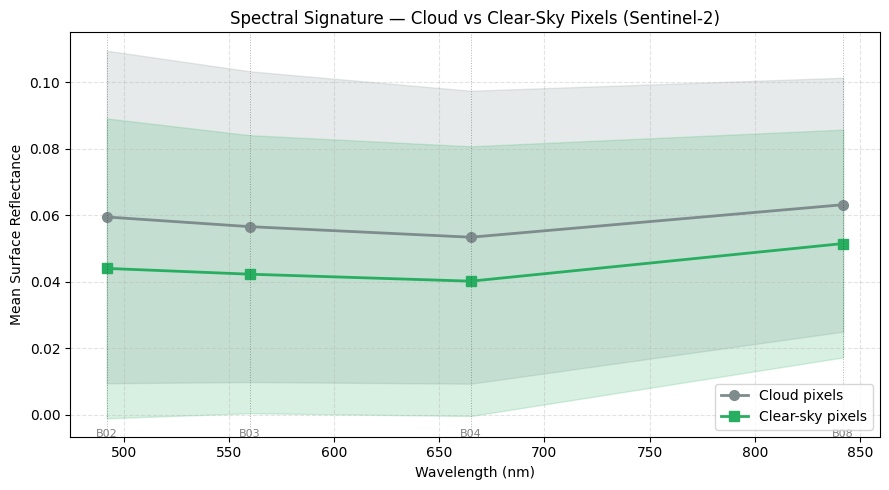

✅ Module 5 done


In [12]:
# ── 5b: Spectral signature of clouds vs clear sky ─────────────────────────────
# Sample N chips and collect band reflectance for cloud & clear pixels
SPEC_N    = min(30, len(chip_folders))
spec_chips = chip_folders[::max(1, len(chip_folders)//SPEC_N)][:SPEC_N]

cloud_refl  = {b: [] for b in BANDS}   # B02,B03,B04,B08
clear_refl  = {b: [] for b in BANDS}

for chip_id in tqdm(spec_chips, desc='Spectral signatures'):
    raw, norm = load_chip(chip_id)
    if norm is None: continue

    prob, mask = get_prob_and_mask(norm)
    cloud_idx  = mask == 1
    clear_idx  = mask == 0

    # raw is (H,W,4) in DN — convert to reflectance [0,1]
    raw_refl = raw / 65535.0

    for bi, band in enumerate(BANDS):
        band_data = raw_refl[:, :, bi]
        if cloud_idx.sum() > 0:
            cloud_refl[band].append(float(band_data[cloud_idx].mean()))
        if clear_idx.sum() > 0:
            clear_refl[band].append(float(band_data[clear_idx].mean()))

# Sentinel-2 band centre wavelengths (nm)
wavelengths = {'B02': 492, 'B03': 560, 'B04': 665, 'B08': 842}
wl_vals     = [wavelengths[b] for b in BANDS]

cloud_means = [np.mean(cloud_refl[b]) for b in BANDS]
cloud_stds  = [np.std(cloud_refl[b])  for b in BANDS]
clear_means = [np.mean(clear_refl[b]) for b in BANDS]
clear_stds  = [np.std(clear_refl[b])  for b in BANDS]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(wl_vals, cloud_means, 'o-', color='#7f8c8d', linewidth=2, markersize=7, label='Cloud pixels')
ax.fill_between(wl_vals,
    np.array(cloud_means)-np.array(cloud_stds),
    np.array(cloud_means)+np.array(cloud_stds),
    alpha=0.18, color='#7f8c8d')

ax.plot(wl_vals, clear_means, 's-', color='#27ae60', linewidth=2, markersize=7, label='Clear-sky pixels')
ax.fill_between(wl_vals,
    np.array(clear_means)-np.array(clear_stds),
    np.array(clear_means)+np.array(clear_stds),
    alpha=0.18, color='#27ae60')

for xi, bi in zip(wl_vals, BANDS):
    ax.axvline(xi, linestyle=':', linewidth=0.7, color='black', alpha=0.3)
    ax.text(xi, ax.get_ylim()[0], bi, ha='center', fontsize=8, color='gray')

ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Mean Surface Reflectance')
ax.set_title('Spectral Signature — Cloud vs Clear-Sky Pixels (Sentinel-2)')
ax.legend()
ax.grid(linestyle='--', alpha=0.35)

plt.tight_layout()
plt.savefig(os.path.join(ADV_DIR, 'spectral_signature_cloud_vs_clear.png'), dpi=150)
plt.show()
print('✅ Module 5 done')

---
# Module 6 — Clearness Index (Kt) & Variability Index (VI)

**Clearness Index** measures how much of the extraterrestrial irradiance reaches the surface:
$$K_t = \frac{G_{\text{surface}}}{G_{\text{max}}} = 1 - \alpha \cdot CC$$

**Variability Index** quantifies day-to-day fluctuations (important for grid stability):
$$VI = \frac{1}{N}\sum_{i=1}^{N}|K_t(i) - K_t(i-1)|$$

High VI = unstable solar resource; Low VI = consistent, grid-friendly.

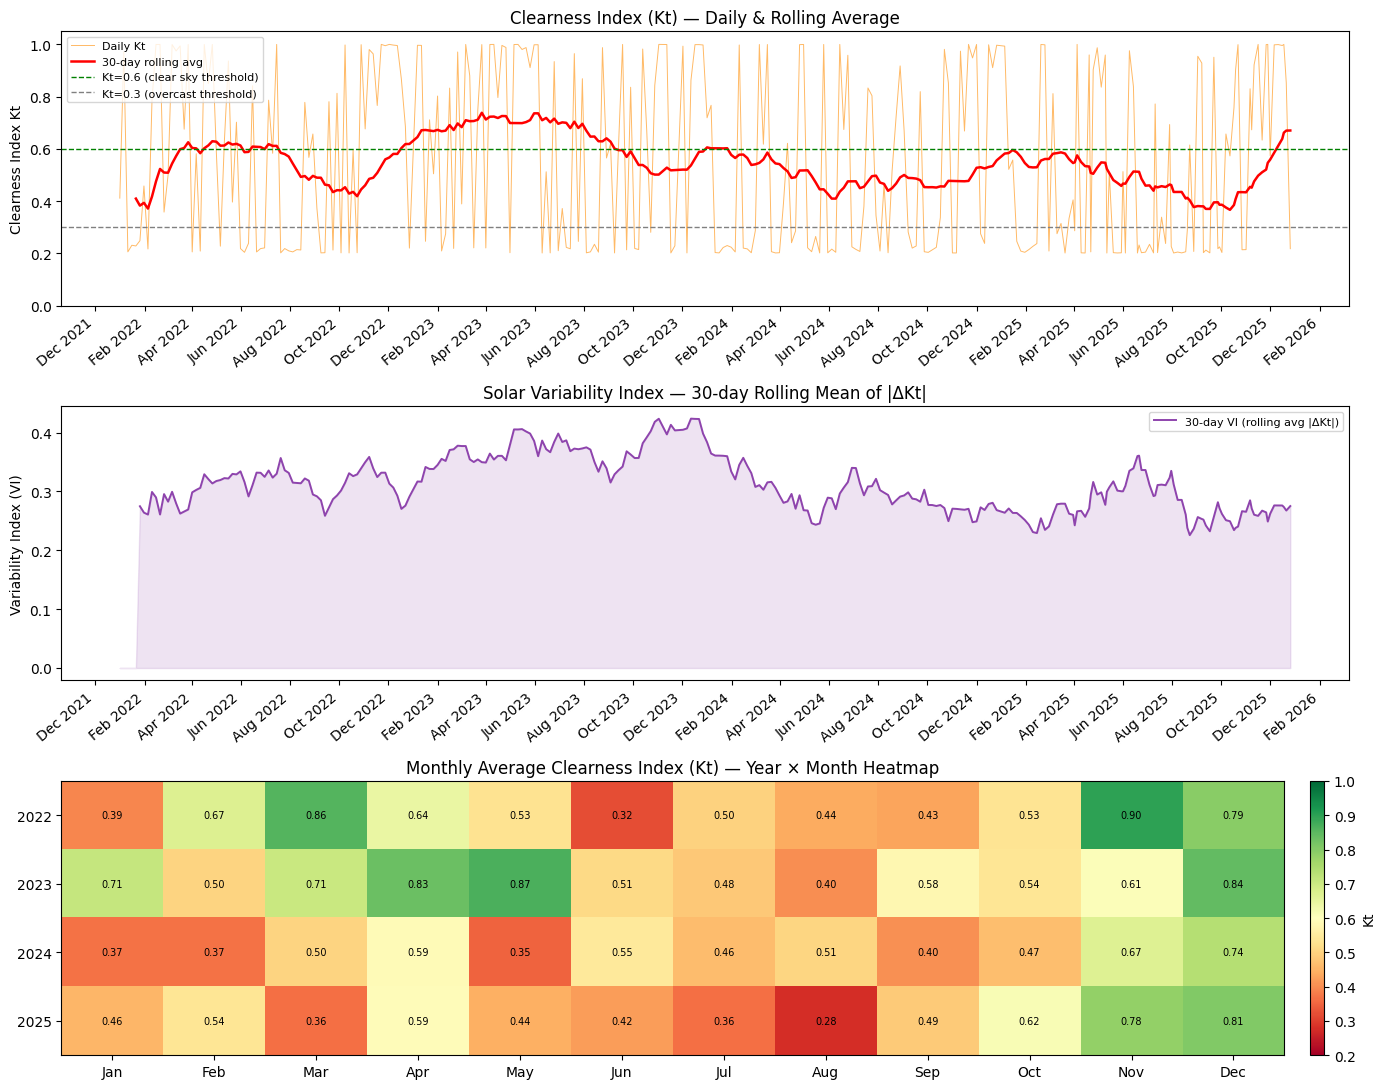

✅ Module 6 done


In [13]:
df_s = df.sort_values('date').copy()

# Clearness index per observation
df_s['Kt'] = df_s['irradiance_wm2'] / I_MAX

# Rolling 30-day variability index
df_s['Kt_diff'] = df_s['Kt'].diff().abs()
df_s['VI_30']   = df_s['Kt_diff'].rolling(30, min_periods=5).mean()

# Monthly Kt and VI
monthly_kt = df_s.groupby(['year','month'])['Kt'].agg(['mean','std']).reset_index()
monthly_vi = df_s.groupby(['year','month'])['Kt_diff'].mean().reset_index()

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=False)

# ── 6a: Kt time series ────────────────────────────────────────────────────────
dates_s = pd.to_datetime(df_s['date'])
axes[0].plot(dates_s, df_s['Kt'], color='darkorange', linewidth=0.7, alpha=0.6, label='Daily Kt')
# 30-day rolling mean
kt_roll = df_s['Kt'].rolling(30, min_periods=5).mean()
axes[0].plot(dates_s, kt_roll, color='red', linewidth=1.8, label='30-day rolling avg')
axes[0].axhline(0.6, linestyle='--', color='green', linewidth=1,  label='Kt=0.6 (clear sky threshold)')
axes[0].axhline(0.3, linestyle='--', color='gray',  linewidth=1,  label='Kt=0.3 (overcast threshold)')
axes[0].set_ylabel('Clearness Index Kt')
axes[0].set_ylim(0, 1.05)
axes[0].set_title('Clearness Index (Kt) — Daily & Rolling Average')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=40, ha='right')
axes[0].legend(fontsize=8)

# ── 6b: Variability Index time series ─────────────────────────────────────────
axes[1].plot(dates_s, df_s['VI_30'], color='#8e44ad', linewidth=1.4, label='30-day VI (rolling avg |ΔKt|)')
axes[1].fill_between(dates_s, df_s['VI_30'].fillna(0), alpha=0.15, color='#8e44ad')
axes[1].set_ylabel('Variability Index (VI)')
axes[1].set_title('Solar Variability Index — 30-day Rolling Mean of |ΔKt|')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=40, ha='right')
axes[1].legend(fontsize=8)

# ── 6c: Monthly Kt heatmap (year × month) ─────────────────────────────────────
kt_pivot = df_s.groupby(['year','month'])['Kt'].mean().unstack(level=1)
kt_pivot = kt_pivot.reindex(columns=range(1, 13))
im = axes[2].imshow(kt_pivot.values, aspect='auto', cmap='RdYlGn',
                     vmin=0.2, vmax=1.0, interpolation='nearest')
axes[2].set_xticks(range(12))
axes[2].set_xticklabels(MONTH_NAMES)
axes[2].set_yticks(range(len(years)))
axes[2].set_yticklabels([str(y) for y in kt_pivot.index])
axes[2].set_title('Monthly Average Clearness Index (Kt) — Year × Month Heatmap')
plt.colorbar(im, ax=axes[2], label='Kt', fraction=0.03, pad=0.02)

# Annotate cells
for row in range(kt_pivot.shape[0]):
    for col in range(kt_pivot.shape[1]):
        val = kt_pivot.values[row, col]
        if not np.isnan(val):
            axes[2].text(col, row, f'{val:.2f}', ha='center', va='center',
                         fontsize=7, color='black')

plt.tight_layout()
plt.savefig(os.path.join(ADV_DIR, 'clearness_variability_index.png'), dpi=150)
plt.show()
print('✅ Module 6 done')

---
# Module 7 — Uncertainty Heatmap

The model outputs a sigmoid probability map. Pixels near **0.5** are the most uncertain (the model is undecided). The uncertainty is quantified as:

$$U(x,y) = 1 - 2\,|p(x,y) - 0.5|$$

So $U=1$ at $p=0.5$ (maximum uncertainty) and $U=0$ at $p=0$ or $p=1$ (maximum confidence).  
We sample N chips, compute and **average** the uncertainty map across chips to get the spatial uncertainty pattern.

In [14]:
UNC_N      = min(20, len(chip_folders))   # number of chips to average over
unc_chips  = chip_folders[::max(1, len(chip_folders)//UNC_N)][:UNC_N]
unc_maps   = []
example_prob  = None
example_mask  = None
example_rgb   = None
example_id    = None

for chip_id in tqdm(unc_chips, desc='Uncertainty maps'):
    raw, norm = load_chip(chip_id)
    if norm is None: continue
    prob, mask = get_prob_and_mask(norm)
    unc = 1.0 - 2.0 * np.abs(prob - 0.5)   # uncertainty map
    unc_maps.append(unc)

    # Keep one example for single-chip plot
    if example_prob is None:
        example_prob = prob
        example_mask = mask
        # RGB from normalized tensor
        t = torch.from_numpy(norm).permute(2,0,1).unsqueeze(0).float().to(device)
        img_np = t[0].cpu().numpy()
        rgb = img_np[[2,1,0],:,:]
        rgb = np.transpose(rgb, (1,2,0))
        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
        example_rgb = rgb
        example_id  = chip_id

avg_unc = np.mean(unc_maps, axis=0)
print(f'Computed uncertainty maps for {len(unc_maps)} chips')
print(f'Avg uncertainty: {avg_unc.mean():.4f}  Max: {avg_unc.max():.4f}')

Uncertainty maps: 100%|████████████████████████████████████████████████████████████████| 20/20 [00:25<00:00,  1.26s/it]

Computed uncertainty maps for 20 chips
Avg uncertainty: 0.0377  Max: 0.3469


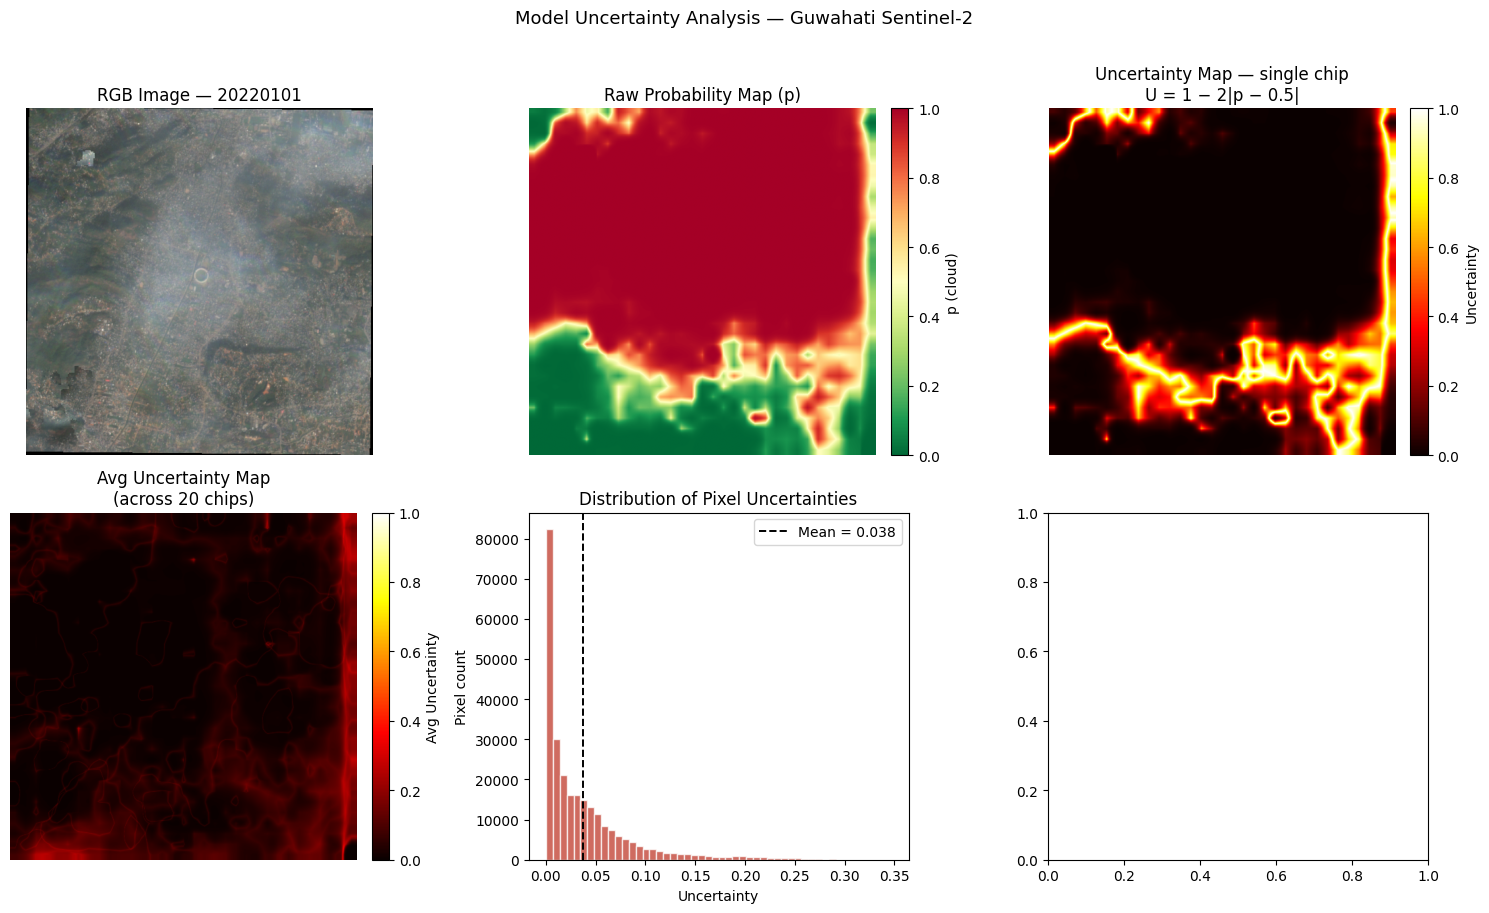

✅ Module 7 done


In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# ── Row 1: example chip ───────────────────────────────────────────────────────
axes[0,0].imshow(example_rgb)
axes[0,0].set_title(f'RGB Image — {example_id}')
axes[0,0].axis('off')

im1 = axes[0,1].imshow(example_prob, cmap='RdYlGn_r', vmin=0, vmax=1)
axes[0,1].set_title('Raw Probability Map (p)')
axes[0,1].axis('off')
plt.colorbar(im1, ax=axes[0,1], fraction=0.046, pad=0.04, label='p (cloud)')

example_unc = 1.0 - 2.0 * np.abs(example_prob - 0.5)
im2 = axes[0,2].imshow(example_unc, cmap='hot', vmin=0, vmax=1)
axes[0,2].set_title('Uncertainty Map — single chip\nU = 1 − 2|p − 0.5|')
axes[0,2].axis('off')
plt.colorbar(im2, ax=axes[0,2], fraction=0.046, pad=0.04, label='Uncertainty')

# ── Row 2: aggregated uncertainty ─────────────────────────────────────────────
im3 = axes[1,0].imshow(avg_unc, cmap='hot', vmin=0, vmax=1)
axes[1,0].set_title(f'Avg Uncertainty Map\n(across {len(unc_maps)} chips)')
axes[1,0].axis('off')
plt.colorbar(im3, ax=axes[1,0], fraction=0.046, pad=0.04, label='Avg Uncertainty')

# ── Histogram of uncertainty values ──────────────────────────────────────────
axes[1,1].hist(avg_unc.ravel(), bins=50, color='#c0392b', alpha=0.75, edgecolor='white')
axes[1,1].axvline(avg_unc.mean(), color='k', linestyle='--', linewidth=1.4,
                  label=f'Mean = {avg_unc.mean():.3f}')
axes[1,1].set_xlabel('Uncertainty')
axes[1,1].set_ylabel('Pixel count')
axes[1,1].set_title('Distribution of Pixel Uncertainties')
axes[1,1].legend()

# ── Uncertainty vs Cloud Cover scatter ───────────────────────────────────────
chip_unc_means = []
chip_cc_vals   = []
for chip_id, unc_map in zip(unc_chips[:len(unc_maps)], unc_maps):
    row = df[df['chip_id'] == chip_id]
    if len(row) > 0:
        chip_cc_vals.append(float(row['cloud_cover_pct'].values[0]))
        chip_unc_means.append(float(unc_map.mean()))

if chip_cc_vals:
    axes[1,2].scatter(chip_cc_vals, chip_unc_means, alpha=0.6, s=30,
                      color='#8e44ad', edgecolors='none')
    axes[1,2].set_xlabel('Cloud Cover (%)')
    axes[1,2].set_ylabel('Mean Pixel Uncertainty')
    axes[1,2].set_title('Uncertainty vs Cloud Cover\n(peak near transition zones)')
    # Trend line
    if len(chip_cc_vals) > 3:
        z = np.polyfit(chip_cc_vals, chip_unc_means, 2)
        xp = np.linspace(min(chip_cc_vals), max(chip_cc_vals), 100)
        axes[1,2].plot(xp, np.poly1d(z)(xp), 'r--', linewidth=1.5, label='Poly fit')
        axes[1,2].legend(fontsize=8)

plt.suptitle('Model Uncertainty Analysis — Guwahati Sentinel-2', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(ADV_DIR, 'uncertainty_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ Module 7 done')

In [16]:
print('=' * 55)
print('ALL ADVANCED OUTPUTS SAVED')
print('=' * 55)
files = [
    'pred_vs_gt.png',
    'yearwise_cloud_irradiance_3line.png',
    'irradiance_block_yearwise.png',
    'solar_power_generation.png',
    'panel_output_summary.png',
    'spectral_signature_cloud_vs_clear.png',
    'clearness_variability_index.png',
    'uncertainty_heatmap.png',
]
for f in files:
    full = os.path.join(ADV_DIR, f)
    status = '✅' if os.path.isfile(full) else '❌ MISSING'
    print(f'  {status}  {f}')

ALL ADVANCED OUTPUTS SAVED
  ✅  pred_vs_gt.png
  ✅  yearwise_cloud_irradiance_3line.png
  ✅  irradiance_block_yearwise.png
  ✅  solar_power_generation.png
  ✅  panel_output_summary.png
  ✅  spectral_signature_cloud_vs_clear.png
  ✅  clearness_variability_index.png
  ✅  uncertainty_heatmap.png
